### Создание модели VGG

In [3]:
import torch
import torch.nn as nn

In [4]:
class VGG11(nn.Module):
    def __init__(self, num_classes=1000, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, (3,3), padding=1),
            nn.ReLU(True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, (3,3), padding=1),
            nn.ReLU(True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(128, 256, (3,3), padding=1),
            nn.ReLU(True),
            nn.Conv2d(256, 256, (3,3), padding=1),
            nn.ReLU(True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(256, 512, (3,3), padding=1),
            nn.ReLU(True),
            nn.Conv2d(512, 512, (3,3), padding=1),
            nn.ReLU(True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(512, 512, (3,3), padding=1),
            nn.ReLU(True),
            nn.Conv2d(512, 512, (3,3), padding=1),
            nn.ReLU(True),
            nn.MaxPool2d(2)
        )

        # self.avgpool = nn.AdaptiveAvgPool2d((7,7))
        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(512*7*7, 4096),
            nn.ReLU(True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        out = self.classifier(x)
        return out

In [5]:
model = VGG11()

input = torch.rand([1,3,224,224], dtype=torch.float32)
output = model(input)
output.shape

torch.Size([1, 1000])

Мы создали модель VGG11. Давайте реализуем класс, с помощью которого можно создавать любую модель VGG

В семействе vgg 4 модели: 11, 13, 16, 19. Все принимают на вход изображение 224*224\*3 

Создадим слорварь, в котором ключ-значения будут название сети - списки 

In [6]:
cfgs = {
    'vgg_11': [64,'M',128,'M',256,256,'M',512,512,'M',512,512,'M'], #M - MaxPool
    'vgg_13': [64,64,'M',128,'M',256,256,'M',512,512,'M',512,512,'M'], 
    'vgg_16': [64,64,'M',128,'M',256,256,256,'M',512,512,512,'M',512,512,512,'M'], 
    'vgg_19': [64,64,'M',128,'M',256,256,256,256,'M',512,512,512,512,'M',512,512,512,512,'M'], 
}

In [7]:
class VGG(nn.Module):
    cfgs = {
    'vgg_11': [64,'M',128,'M',256,256,'M',512,512,'M',512,512,'M'],
    'vgg_13': [64,64,'M',128,'M',256,256,'M',512,512,'M',512,512,'M'], 
    'vgg_16': [64,64,'M',128,'M',256,256,256,'M',512,512,512,'M',512,512,512,'M'], 
    'vgg_19': [64,64,'M',128,'M',256,256,256,256,'M',512,512,512,512,'M',512,512,512,512,'M'], 
}

    def __init__(self, name, num_classes=1000, dropout=0.5):
        super().__init__()
        self.cfg = self.cfgs[name]

        self.features = self.make_layers(self.cfg)
        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(512*7*7,4096),
            nn.ReLU(True),
            nn.Dropout(p=dropout),
            nn.Linear(4096,4096),
            nn.ReLU(True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        out = self.classifier(x)
        return out

    def make_layers(self, cfg):
        layers = []
        in_channels = 3
        for value in cfg:
            if value == 'M':
                layers += [nn.MaxPool2d(2)]
            else:
                conv2d = nn.Conv2d(in_channels,value,(3,3),padding=1)
                layers += [conv2d, nn.ReLU(True)]
                in_channels = value
        return nn.Sequential(*layers)

In [8]:
model = VGG('vgg_19')
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [10]:
input = torch.rand([1,3,224,224], dtype=torch.float32)
output = model(input)
output.shape

torch.Size([1, 1000])

### Готовые архитектуры VGG в torchvision 

In [12]:
import torchvision
from torchvision import models
from torchvision.transforms import v2
import torchvision.transforms as v1
import matplotlib.pyplot as plt
from PIL import Image

In [16]:
vgg11 = models.vgg11()
vgg19 = models.vgg19(weights='DEFAULT')

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\arato/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:20<00:00, 27.9MB/s] 


In [17]:
input = torch.rand([1,3,224,224],dtype=torch.float32)
pred = vgg19(input)
pred.shape

torch.Size([1, 1000])

Обученные веса моделей

In [19]:
weights_vgg11=models.VGG11_Weights.IMAGENET1K_V1
weights_vgg13=models.VGG13_Weights.DEFAULT
weights_vgg16=models.VGG16_Weights.IMAGENET1K_V1
weights_vgg19=models.VGG19_Weights.DEFAULT

In [21]:
vgg16 = models.vgg16(weights=weights_vgg16)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\arato/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [00:22<00:00, 25.1MB/s] 


Ссылка для скачивания обученных весов модели

In [22]:
url = weights_vgg19.url
url

'https://download.pytorch.org/models/vgg19-dcbb9e9d.pth'

Трансформации, которые применялись к изображениям при тренировке

In [23]:
transforms_default = weights_vgg19.transforms()
transforms_default

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

Список с именами классов

In [24]:
class_names = weights_vgg19.meta['categories']
print(type(class_names))
print(len(class_names))
print(class_names[:5])

<class 'list'>
1000
['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


### Предсказания обученной модели

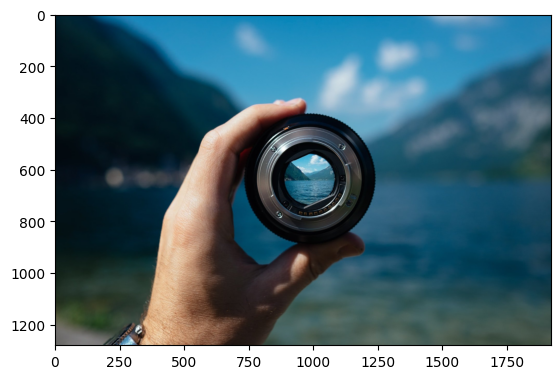

In [27]:
img = Image.open('photo.jpg')
plt.imshow(img)

Обычные преобразования

In [28]:
transforms_default = weights_vgg19.transforms()

Преобразования на основе модуля v1 (transforms)

In [30]:
size = 224

trans_v1 = v1.Compose([
    v1.Resize(256),
    v1.CenterCrop(size),
    v1.ToTensor(),
    v1.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
])

Преобразования на основе модуля v2

In [32]:
size = 224

trans_v2 = v2.Compose([
    v2.ToImage(),
    v2.Resize(256),
    v2.CenterCrop(size),
    v2.ToDtype(dtype=torch.float32,scale=True),
    v2.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
])

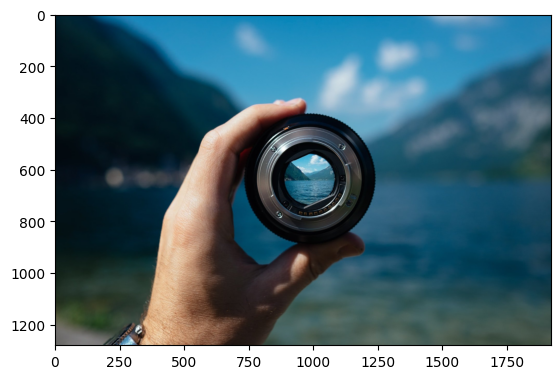

transform_default:
binoculars => 0.63425
loupe => 0.35497
lens cap => 0.00297
reflex camera => 0.00286
oil filter => 0.00098
spotlight => 0.00072

transform_v1:
binoculars => 0.63425
loupe => 0.35497
lens cap => 0.00297
reflex camera => 0.00286
oil filter => 0.00098
spotlight => 0.00072

transform_v2:
binoculars => 0.63425
loupe => 0.35497
lens cap => 0.00297
reflex camera => 0.00286
oil filter => 0.00098
spotlight => 0.00072



In [37]:
transforms = {
    'transform_default':transforms_default,
    'transform_v1':trans_v1,
    'transform_v2':trans_v2,
}

plt.imshow(img)
plt.show()

vgg19.eval()
for name, transform in transforms.items():
    print(f'{name}:')
    img_in = transform(img).unsqueeze(dim=0) # img => transform => (3, 224, 224) => unsqueeze => (1, 3, 224, 224) =>img_in
    pred = vgg19(img_in).squeeze() # (1, 1000) => (1000)

    sorted, indices = pred.softmax(dim=0).sort(descending=True)
    for i, (s,ind) in enumerate(zip(sorted,indices)):
        print(f'{class_names[ind]} => {s:.5f}')
        if i//5:
            break
    print('=========================',end='\n\n')

При разных преобразованиях изображения идентифицировала объектив как лупу/бинокль, но с разной степенью уверенности